In [1]:
# %load_ext autoreload
# %autoreload 2
import os, sys

import PATH
import scanpy as sc
import anndata as ad
import numpy as np
from src import _sampler
from src import _learner
from src import _reader

import torch
from torch import nn
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import scvelo

In [3]:
from src._configure import Yaml_configurer

sys.path.append(os.path.join(PATH.main_dir, "script"))

from script.main_train_with_PL_trainer import dl_from_config, get_model_from_config, get_sampler_from_configs
import PATH
from src import _diffplot as dfp
import pandas as pd

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [4]:
from script.main_train_with_PL_trainer import dl_from_config

In [25]:
adata = sc.read_h5ad(os.path.join(PATH.main_dir, "data/TFAtlas/differentiated_model_velo.h5ad"))

# condition embedding

In [77]:
###.  TF subs
# path = f"{PATH.main_dir}/configs/TF_atlas/TF_subs/large_batch.yaml"
# configs = Yaml_configurer(path)
# ckpt = f"{PATH.pth_dir}/TF_subs/Epsilon_Linear_large_batch/lightning_logs/version_0/checkpoints/epoch=0-step=4250.ckpt"

###  H32 d3
path = f"{PATH.main_dir}/configs/TF_atlas/TF_diff/H32_d3.yaml"
configs = Yaml_configurer(path)
ckpt = f"{PATH.pth_dir}/TF_diff/Epsilon_Linear_H32_d3/lightning_logs/version_0/checkpoints/epoch=4-step=3650.ckpt"

In [79]:
device = 0
eps_net = get_model_from_config(configs, device)

Sampler_pl_module = eval("_learner."+configs.sampler_class)

model = Sampler_pl_module.load_from_checkpoint(ckpt, model=eps_net).to('cpu')
model.eval();

In [80]:
embedder = model.model.embedder.weight.detach().numpy()

In [81]:
embedder.shape

(3551, 32)

In [26]:
TF_summary = adata.obs.groupby("TF").agg({'dpt_pseudotime':"max",
                            "split" : 'count'
                             })

In [27]:
large_dpt_TF = TF_summary.dpt_pseudotime.nlargest(200).index

In [105]:
cluster_eTFs = ['TFORF0365-TCEB1',
 'TFORF0050-MAZ',
 'TFORF0297-CREM',
 'TFORF0987-KLF2',
 'TFORF0983-KLF5',
 'TFORF0984-KLF5',
 'TFORF2848-TCF21',
 'TFORF3361-MSC',
 'TFORF0926-ATOH7',
 'TFORF0988-KLF1',
 'TFORF0518-PAX5',
 'TFORF0537-PAX2',
 'TFORF0514-PAX5',
 'TFORF0985-KLF4',
 'TFORF0873-HOXB8',
 'TFORF0270-TCF7',
 'TFORF3363-NR5A1',
 'TFORF1447-NR5A2',
 'TFORF3131-NR5A2',
 'TFORF2883-BHLHA9',
 'TFORF2062-NKX2-6',
 'TFORF0098-MSGN1',
 'TFORF1324-KLF17',
 'TFORF2779-BATF',
 'TFORF0086-LIN28B',
 'TFORF2478-MESP1',
 'TFORF0391-FERD3L',
 'TFORF2496-ASCL3',
 'TFORF2498-ASCL4',
 'TFORF1216-NHLH1',
 'TFORF1159-EOMES',
 'TFORF2055-CDX1',
 'TFORF3008-CDX2',
 'TFORF1468-HOXD11',
 'TFORF0902-PTF1A',
 'TFORF1306-ZSCAN9',
 'TFORF2786-GLIS1',
 'TFORF2785-GLIS1',
 'TFORF0032-GSC2',
 'TFORF2168-GRHL3',
 'TFORF1167-EBF3',
 'TFORF2165-GRHL3',
 'TFORF0693-HNF4A',
 'TFORF0694-HNF4A',
 'TFORF0692-HNF4A',
 'TFORF1328-TFAP2A',
 'TFORF1829-DMRTA2',
 'TFORF0607-CREBL2',
 'TFORF2744-T',
 'TFORF1550-TAZ',
 'TFORF2078-FLI1',
 'TFORF0254-CAMTA1',
 'TFORF1241-LBX2',
 'TFORF0822-LHX6',
 'TFORF0820-LHX6',
 'TFORF0821-LHX6',
 'TFORF1688-HNF1A',
 'TFORF1689-HNF1A']

TF_colors = ['#ffff00',
 '#1ce6ff',
 '#ff34ff',
 '#ff4a46',
 '#008941',
 '#006fa6',
 '#a30059',
 '#ffdbe5',
 '#7a4900',
 '#0000a6',
 '#63ffac',
 '#b79762',
 '#004d43',
 '#8fb0ff',
 '#997d87',
 '#5a0007',
 '#809693',
 '#6a3a4c',
 '#1b4400',
 '#4fc601',
 '#3b5dff',
 '#4a3b53',
 '#ff2f80',
 '#61615a',
 '#ba0900',
 '#6b7900',
 '#00c2a0',
 '#ffaa92',
 '#ff90c9',
 '#b903aa',
 '#d16100',
 '#ddefff',
 '#000035',
 '#7b4f4b',
 '#a1c299',
 '#300018',
 '#0aa6d8',
 '#013349',
 '#00846f',
 '#372101',
 '#ffb500',
 '#c2ffed',
 '#a079bf',
 '#cc0744',
 '#c0b9b2',
 '#c2ff99',
 '#001e09',
 '#00489c',
 '#6f0062',
 '#0cbd66',
 '#eec3ff',
 '#456d75',
 '#b77b68',
 '#7a87a1',
 '#788d66',
 '#885578',
 '#fad09f',
 '#ff8a9a',
 '#d4d2d2']

In [83]:
token_lokup = adata.uns['unique_token_dict']
unique_TF = adata.obs.TF.unique()

In [84]:
existed_TF = [token_lokup[tf] for tf in adata.obs.TF.unique()]
existed_emb = embedder[existed_TF,:]

In [85]:
large_dpt_token = [token_lokup[tf] for tf in large_dpt_TF]
large_dpt_emb = embedder[large_dpt_token,:]

In [137]:
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA, PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
import seaborn as sns
from umap import UMAP

In [86]:
cluster_enrich_token = [token_lokup[tf] for tf in cluster_eTFs]
cluster_enrich_emb = embedder[cluster_enrich_token,:]

In [87]:
emb_Kpca = KernelPCA(kernel='rbf').fit(cluster_enrich_emb)
emb_Kpca_ay = emb_Kpca.transform(cluster_enrich_emb)

In [138]:
emb_pca=PCA().fit(cluster_enrich_emb)
emb_pca_ay=emb_pca.transform(cluster_enrich_emb)

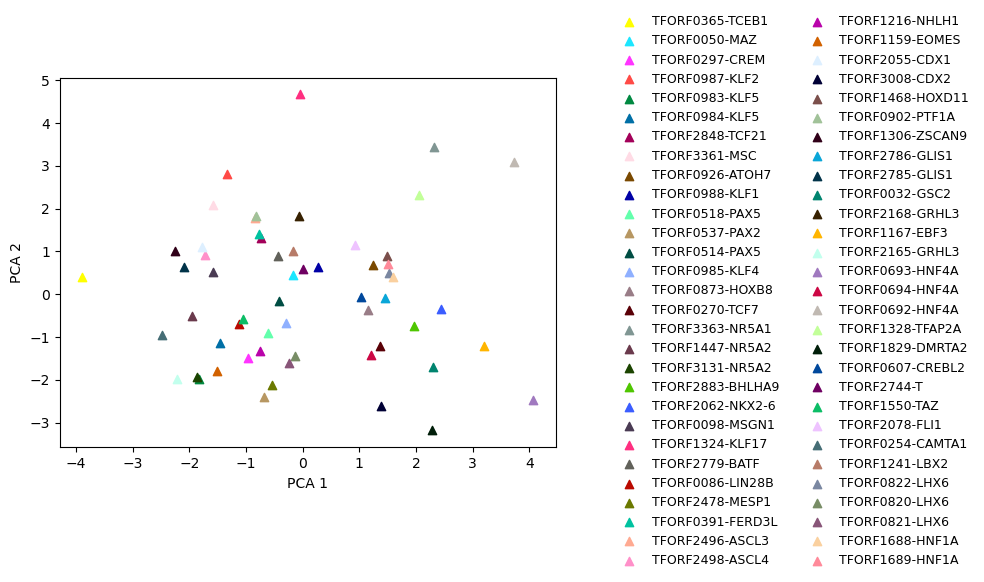

In [158]:
fig, ax = plt.subplots(1,1)
for i, (t,c) in enumerate(zip(cluster_eTFs,TF_colors)):
    ax.scatter( emb_pca_ay[i,0],  emb_pca_ay[i,1], color=c,
            marker='^',label=t)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
plt.legend(ncol=2, fontsize=9, frameon=False, bbox_to_anchor = [1.1, 1.2])

Text(0, 0.5, 'Kernel PCA 4')

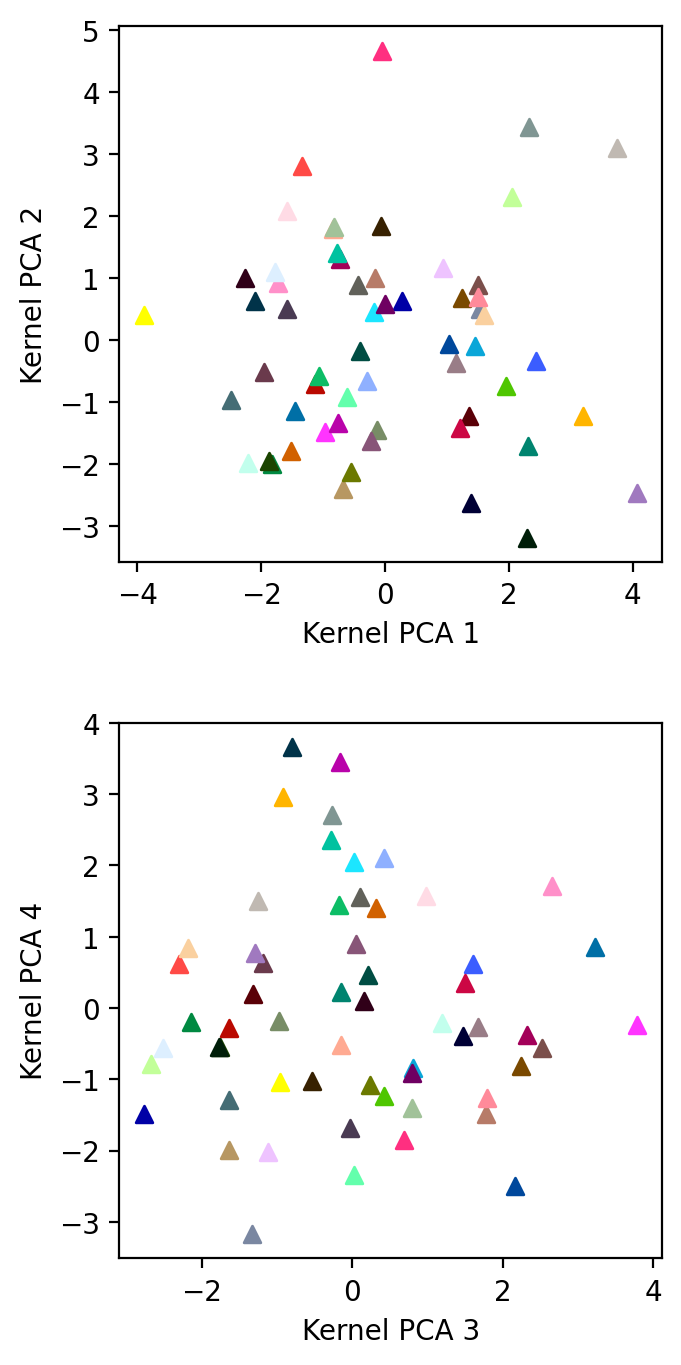

In [161]:
fig, ax = plt.subplots(2,1, figsize=(3.5, 8), dpi=200, gridspec_kw={"hspace":0.3})
for i, (t,c) in enumerate(zip(cluster_eTFs,TF_colors)):
    
    ax[0].scatter( emb_pca_ay[i,0],  emb_pca_ay[i,1], color=c,
            marker='^',label=t)
    ax[1].scatter( emb_pca_ay[i,2],  emb_pca_ay[i,3], color=c,
            marker='^',label=t)
    
ax[0].set_xlabel("Kernel PCA 1")
ax[0].set_ylabel("Kernel PCA 2")

ax[1].set_xlabel("Kernel PCA 3")
ax[1].set_ylabel("Kernel PCA 4")

In [90]:
euclidean_umap = UMAP(n_neighbors = 15, 
                      metric = "euclidean", 
                      output_metric = 'euclidean').fit_transform(cluster_enrich_emb)

In [91]:
cosine_umap = UMAP(n_neighbors = 15, 
                   metric = "cosine", 
                   output_metric = 'euclidean').fit_transform(cluster_enrich_emb)

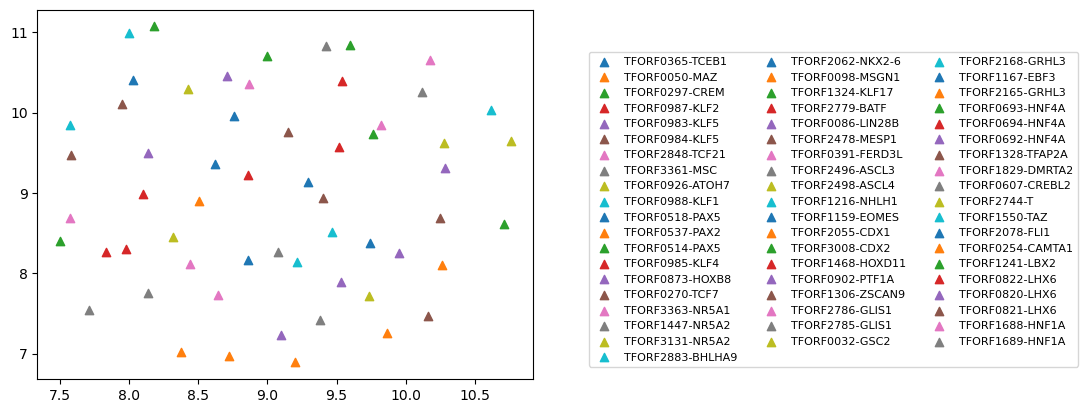

In [ ]:
fig, ax = plt.subplots(1,1)
for i, t in enumerate(cluster_eTFs):
    ax.scatter( euclidean_umap[i,0],  euclidean_umap[i,1], 
            marker='^',label=t)
    
plt.legend(ncol=3, fontsize=8, bbox_to_anchor = [1.1, 0.9])

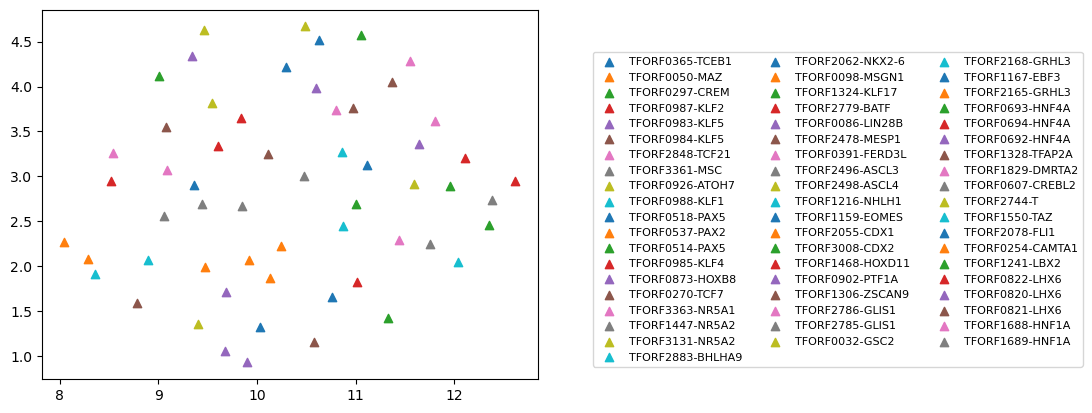

In [93]:
fig, ax = plt.subplots(1,1)
for i, t in enumerate(cluster_eTFs):
    ax.scatter( cosine_umap[i,0],  cosine_umap[i,1], 
            marker='^',label=t)
    
plt.legend(ncol=3, fontsize=8, bbox_to_anchor = [1.1, 0.9])

In [132]:
from sklearn.preprocessing import StandardScaler

In [154]:
# similarity_m = cosine_similarity(cluster_enrich_emb)

similarity_m =  - euclidean_distances(cluster_enrich_emb)
similarity_m = (similarity_m - similarity_m.min())/(similarity_m.max() - similarity_m.min())
# similarity_m = StandardScaler().fit_transform(eucli_d)

# similarity_m = rbf_kernel(cluster_enrich_emb)

In [155]:
for i in range(similarity_m.shape[0]):
    similarity_m[i,i] = 0

In [ ]:
sim_df = pd.DataFrame(similarity_m, columns=cluster_eTFs, index=cluster_eTFs)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


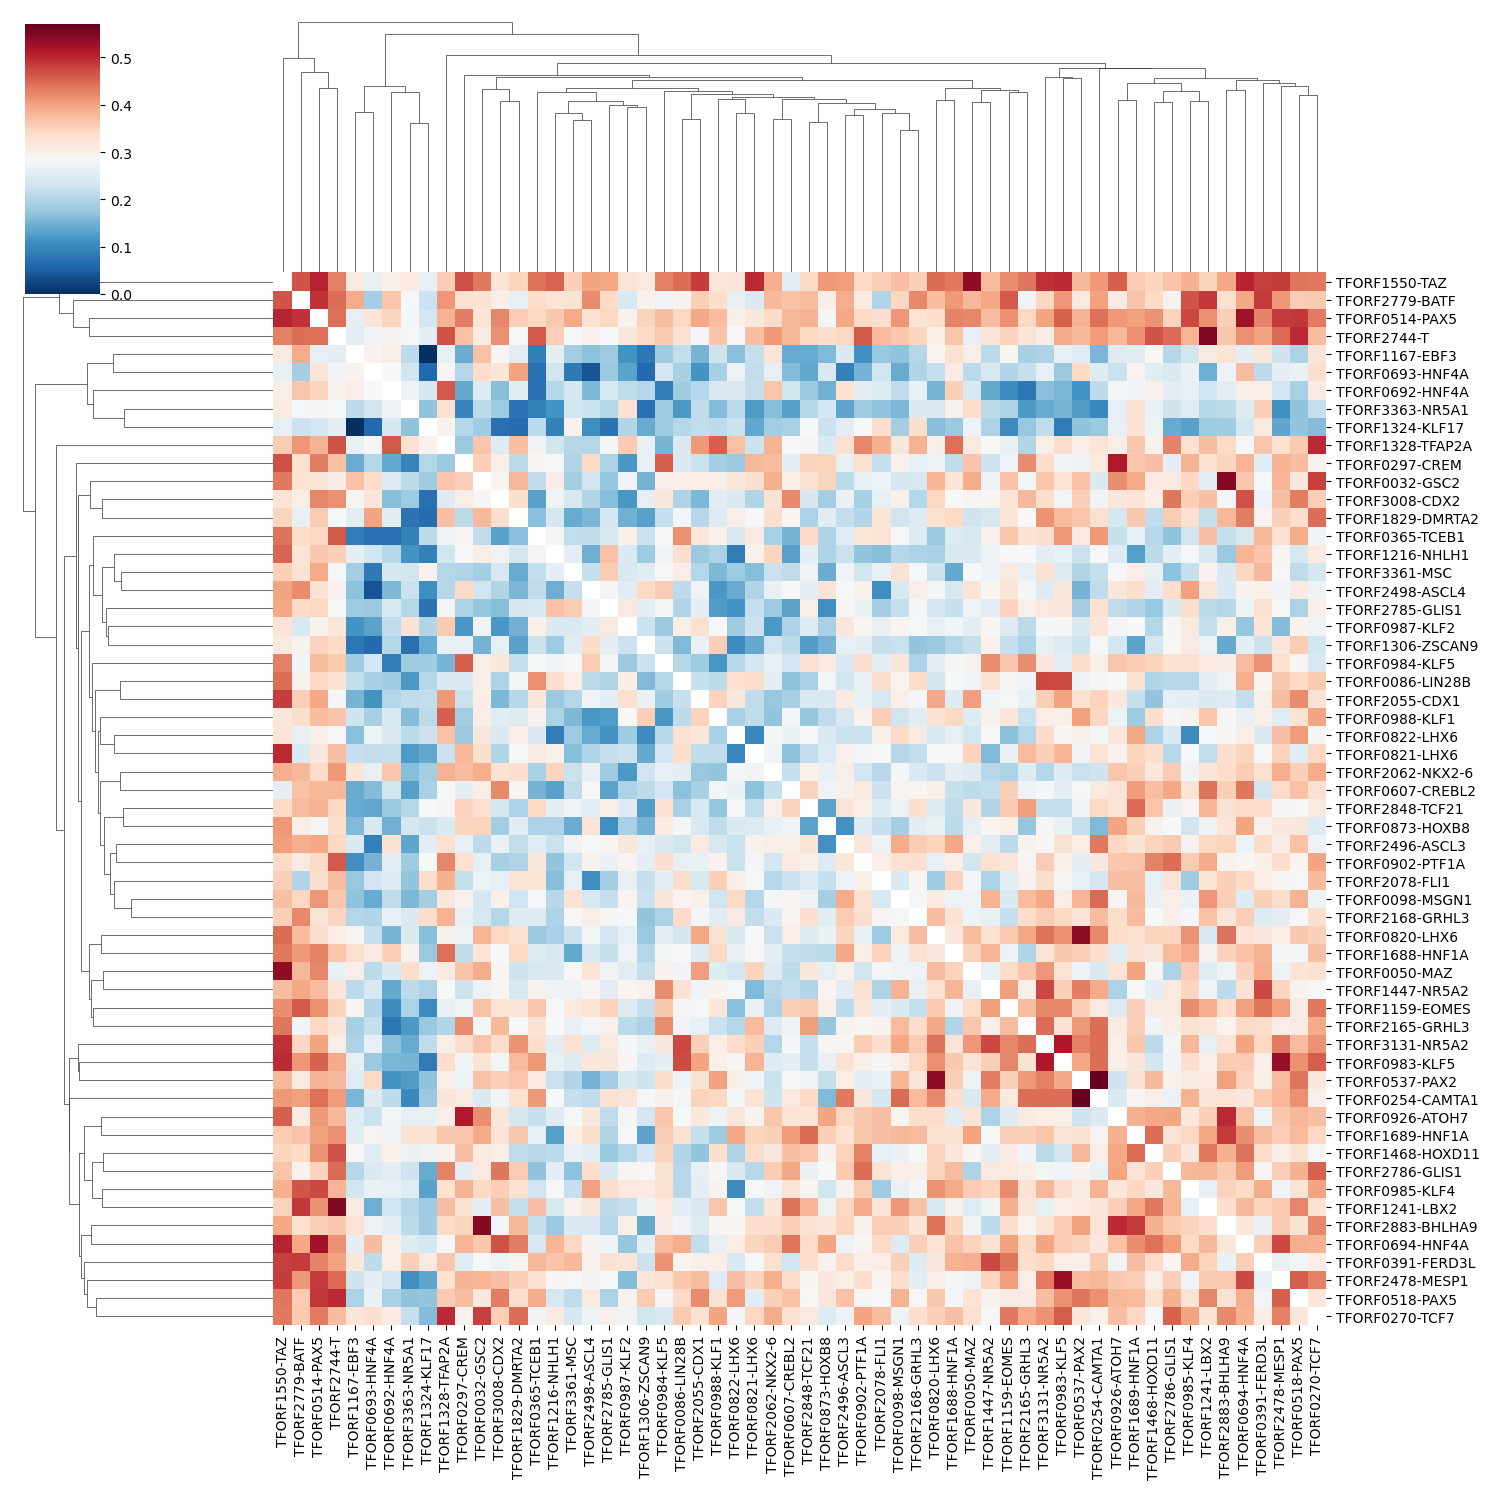

In [ ]:
sns.clustermap(data=sim_df, mask=np.diag(np.ones((cosine_m.shape[0]),)),
                cmap='RdBu_r', figsize=(15,15))